# Random Forest

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

print("Libraries imported! ✅")

Libraries imported! ✅


In [2]:
# Cell 2 — Load churn dataset
df = pd.read_csv(r"C:\Users\MINHAJ\Downloads\Data Set For Task-20260408T161732Z-3-001\Data Set For Task\Churn Prdiction Data\churn-bigml-80.csv")

print("Shape:", df.shape)
df.head()

Shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
# Encode categorical columns
le = LabelEncoder()
categorical_cols = ['State', 'International plan', 'Voice mail plan', 'Churn']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale and Split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Data ready! ✅")

Training samples: 2132
Testing samples: 534
Data ready! ✅


In [4]:
# Train with tuned hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees in the forest
    max_depth=10,        # max depth of each tree
    min_samples_split=5,
    random_state=42
)
rf_model.fit(X_train, y_train)

print("Random Forest trained! ✅")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Number of features: {rf_model.n_features_in_}")

Random Forest trained! ✅
Number of trees: 100
Number of features: 19


In [5]:
# Cross-validation — tests model on 5 different splits
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='accuracy')

print("=== CROSS-VALIDATION RESULTS ===")
print(f"Scores per fold: {[f'{s:.2%}' for s in cv_scores]}")
print(f"Mean Accuracy:   {cv_scores.mean():.2%}")
print(f"Std Deviation:   {cv_scores.std():.2%}")

=== CROSS-VALIDATION RESULTS ===
Scores per fold: ['95.13%', '93.43%', '95.31%', '95.87%', '94.93%']
Mean Accuracy:   94.94%
Std Deviation:   0.81%


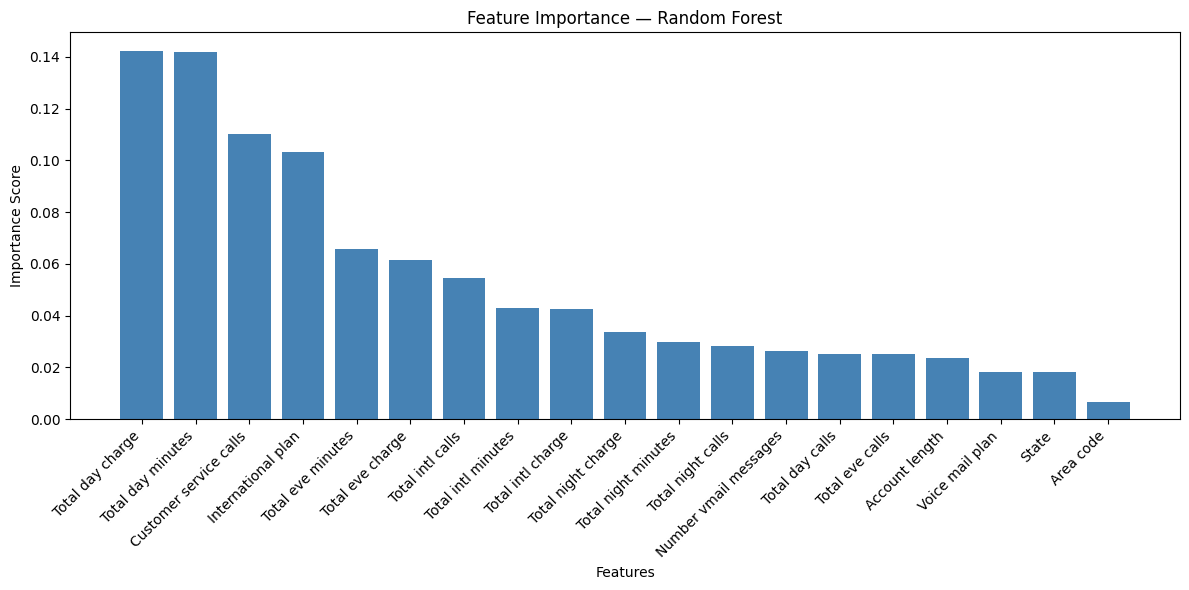


Top 5 most important features:
  1. Total day charge: 0.1423
  2. Total day minutes: 0.1418
  3. Customer service calls: 0.1103
  4. International plan: 0.1034
  5. Total eve minutes: 0.0659


In [6]:
# Which features matter most for predicting churn?
feature_names = df.drop('Churn', axis=1).columns
importances = rf_model.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), 
        importances[indices], color='steelblue')
plt.xticks(range(len(importances)), 
           feature_names[indices], rotation=45, ha='right')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

print("\nTop 5 most important features:")
for i in range(5):
    print(f"  {i+1}. {feature_names[indices[i]]}: "
          f"{importances[indices[i]]:.4f}")

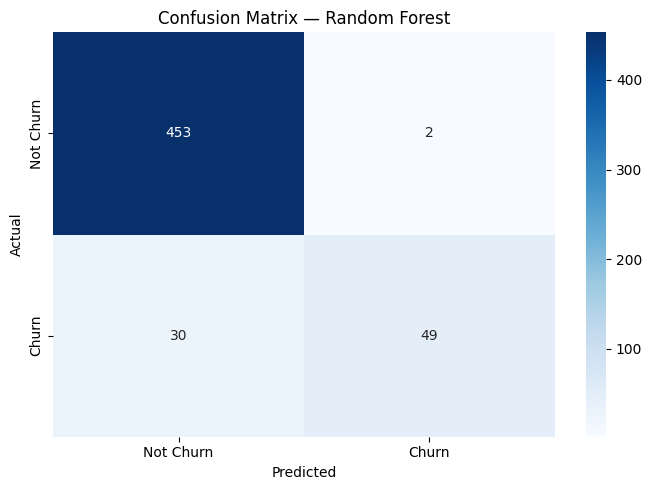

Task 5 - Random Forest Complete! ✅


In [8]:
# Re-predict then plot confusion matrix
y_pred = rf_model.predict(X_test)

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png")
plt.show()
print("Task 5 - Random Forest Complete! ✅")